In [1]:
# ==========================================================
# Imports and autoreload
# ==========================================================

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from pathlib import Path

import frb_isotropy as iso

import warnings
from frb_isotropy import suppress_library_warnings

suppress_library_warnings()

In [2]:
# ==========================================================
# Paths
# ==========================================================

# Main directory
MAIN_DIR = Path.cwd()

# Catalog
CATALOG_PATH = (
    MAIN_DIR / "SkyPosition.csv"
)

# Outputs directory
OUTPUTS_ROOT = (
    MAIN_DIR / "outputs"
)

# ==========================================================
# Create directories
# ==========================================================

OUTPUTS_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

In [3]:
# ==========================================================
# Explicit analysis configuration
# ==========================================================

RUN_CONFIG = iso.AnalysisConfig(

    # ------------------------------------------------------
    # Metadata
    # ------------------------------------------------------

    name="weightedisotropy",

    # ------------------------------------------------------
    # Filesystem
    # ------------------------------------------------------

    project_root=MAIN_DIR,

    outputs_root=OUTPUTS_ROOT,
    
    catalog_path=CATALOG_PATH,

    # ------------------------------------------------------
    # Physical model
    # ------------------------------------------------------

    use_gal_mask=False,

    use_sel_func=True,

    # ------------------------------------------------------
    # Parallelization
    # ------------------------------------------------------

    n_jobs=100,

    # ------------------------------------------------------
    # Galactic masking
    # ------------------------------------------------------

    gal_cut=20.0,

    # ------------------------------------------------------
    # Angular statistics
    # ------------------------------------------------------

    min_sep=0.0,

    max_sep=180.0,

    bin_size=10.0,

    coarse_bins=tuple(
        np.arange(0, 181, 20)
    ),

    # ------------------------------------------------------
    # Selection functions
    # ------------------------------------------------------

    nside_sf=64,

    smooth_sigma=3.0,

    # ------------------------------------------------------
    # H0 perturbations
    # ------------------------------------------------------

    perturbation_scale=1.0,

    # ------------------------------------------------------
    # Random catalogs
    # ------------------------------------------------------

    n_rand_factor=20,

    # ------------------------------------------------------
    # H0 ensemble
    # ------------------------------------------------------

    n_ensemble=20,

    n_mocks_per_ensemble=50,

    # ------------------------------------------------------
    # Covariance regularization
    # ------------------------------------------------------

    svd_eigenvalue_cut=1e-2,

    # ------------------------------------------------------
    # Numerical stability
    # ------------------------------------------------------

    numerical_zero_tolerance = 1e-30,


    # ------------------------------------------------------
    # Jackknife
    # ------------------------------------------------------

    nside_jackknife=4,

    min_jackknife_regions=20,

    # ------------------------------------------------------
    # Bootstrap
    # ------------------------------------------------------

    n_bootstrap=500,

    # ------------------------------------------------------
    # Overlap analysis
    # ------------------------------------------------------

    overlap_radius_deg=5.0,

    overlap_nside=32,
)

# ==========================================================
# Runtime context
# ==========================================================

context = iso.create_runtime_context(
    RUN_CONFIG
)

iso.log_runtime_configuration(
    context
)


FRB ISOTROPY PIPELINE
RUN TAG                  : weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3
PROJECT ROOT             : /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main
CATALOG PATH             : /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/SkyPosition.csv
OUTPUT ROOT              : /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs
USE GAL MASK             : False
USE SEL FUNC             : True
N JOBS                   : 100
GAL CUT                  : 20.0
MIN SEP                  : 0.0
MAX SEP                  : 180.0
BIN SIZE                 : 10.0
N BINS                   : 18
COARSE BINS              : (np.int64(0), np.int64(20), np.int64(40), np.int64(60), np.int64(80), np.int64(100), np.int64(120), np.int64(140), np.int64(160), np.int64(180))
NSIDE SF                 : 64
SMOOTH SIGMA             : 3.0
PERTURBATION SCALE       : 1.0
N RAND FACTOR            : 20
N ENSEMBLE               : 20
N MOCKS PER ENSEMBLE     : 50
TOTAL H0 MO

In [4]:
# ==========================================================
# Runtime switches
# ==========================================================

SAVE_OUTPUTS = True

RUN_TOP_SURVEY_MAPS = True

In [5]:
# ==========================================================
# Load and mask observed catalog
# ==========================================================

print("\n==================================================")
print("LOAD OBSERVED CATALOG")
print("==================================================")

df_data = iso.load_catalog(
    context
)

df_data = iso.apply_mask(
    context,
    df_data,
)

print(
    f"Masked catalog size: "
    f"{len(df_data)}"
)

if len(df_data) < 10:

    raise RuntimeError(
        "Catalog too small after masking."
    )


LOAD OBSERVED CATALOG

--- Catalog loaded ---
Objects: 4480

--- Galactic mask disabled ---
Masked catalog size: 4480


In [6]:
# ==========================================================
# Build survey selection functions
# ==========================================================

print("\n==================================================")
print("SELECTION FUNCTIONS")
print("==================================================")

selection_functions = (
    iso.build_survey_selection_functions_improved(

        context=context,

        df_data=df_data,

        nside=RUN_CONFIG.nside_sf,

        smooth_sigma=RUN_CONFIG.smooth_sigma,
    )
)

# ----------------------------------------------------------
# Convenience aliases
# ----------------------------------------------------------

if selection_functions is not None:

    sf_dict = (
        selection_functions.sf_dict
    )

    sf_cov_diag_dict = (
        selection_functions.sf_cov_diag_dict
    )

    survey_weights = (
        selection_functions.survey_weights
    )

    sf_nside = (
        selection_functions.nside
    )

else:

    sf_dict = None

    sf_cov_diag_dict = None

    survey_weights = None

    sf_nside = None


SELECTION FUNCTIONS

--- Survey partitioning ---
Unique surveys: 21

Survey populations:
          CHIME | N=4093 |  91.36%
         FRBCAT | N= 132 |   2.95%
          CRAFT | N= 103 |   2.30%
         PARKES | N=  81 |   1.81%
          ALERT | N=  23 |   0.51%
       MeerTRAP | N=  12 |   0.27%
           FAST | N=  11 |   0.25%
     Pan-STARRS | N=   4 |   0.09%
          ATLAS | N=   4 |   0.09%
   VLA-realfast | N=   4 |   0.09%
     GaiaAlerts | N=   4 |   0.09%
         UTMOST | N=   4 |   0.09%
            ZTF | N=   1 |   0.02%
         ALeRCE | N=   1 |   0.02%
        Tianlai | N=   1 |   0.02%
         TRAPUM | N=   1 |   0.02%
          PALFA | N=   1 |   0.02%
     VLITE-Fast | N=   1 |   0.02%
          GBNCC | N=   1 |   0.02%
         MASTER | N=   1 |   0.02%
        ASAS-SN | N=   1 |   0.02%

--- Building selection functions ---
Unique surveys: 21
Adaptive smoothing: False
            ZTF | N=   1 | sigma= 3.0 deg | weight=0.0002
          CRAFT | N= 103 | sigma= 


SELECTION FUNCTION VALIDATION

CHIME:
  Weight: 91.28%
  Peak density: RA=347.7 deg, DEC=48.9 deg
  Active coverage: 56.1%
  Entropy: 13.93 bits

FRBCAT:
  Weight: 2.94%
  Peak density: RA=83.0 deg, DEC=33.5 deg
  Active coverage: 30.4%
  Entropy: 12.62 bits

CRAFT:
  Weight: 2.30%
  Peak density: RA=93.5 deg, DEC=4.8 deg
  Active coverage: 19.2%
  Entropy: 10.79 bits

PARKES:
  Weight: 1.81%
  Peak density: RA=15.0 deg, DEC=-74.6 deg
  Active coverage: 21.9%
  Entropy: 12.65 bits

ALERT:
  Weight: 0.51%
  Peak density: RA=332.6 deg, DEC=15.7 deg
  Active coverage: 7.8%
  Entropy: 10.82 bits

MeerTRAP:
  Weight: 0.27%
  Peak density: RA=259.0 deg, DEC=-50.5 deg
  Active coverage: 7.7%
  Entropy: 10.93 bits

FAST:
  Weight: 0.25%
  Peak density: RA=296.7 deg, DEC=22.7 deg
  Active coverage: 6.2%
  Entropy: 10.59 bits

Pan-STARRS:
  Weight: 0.09%
  Peak density: RA=2.8 deg, DEC=-36.4 deg
  Active coverage: 3.5%
  Entropy: 9.52 bits

ATLAS:
  Weight: 0.09%
  Peak density: RA=283.4 deg, D

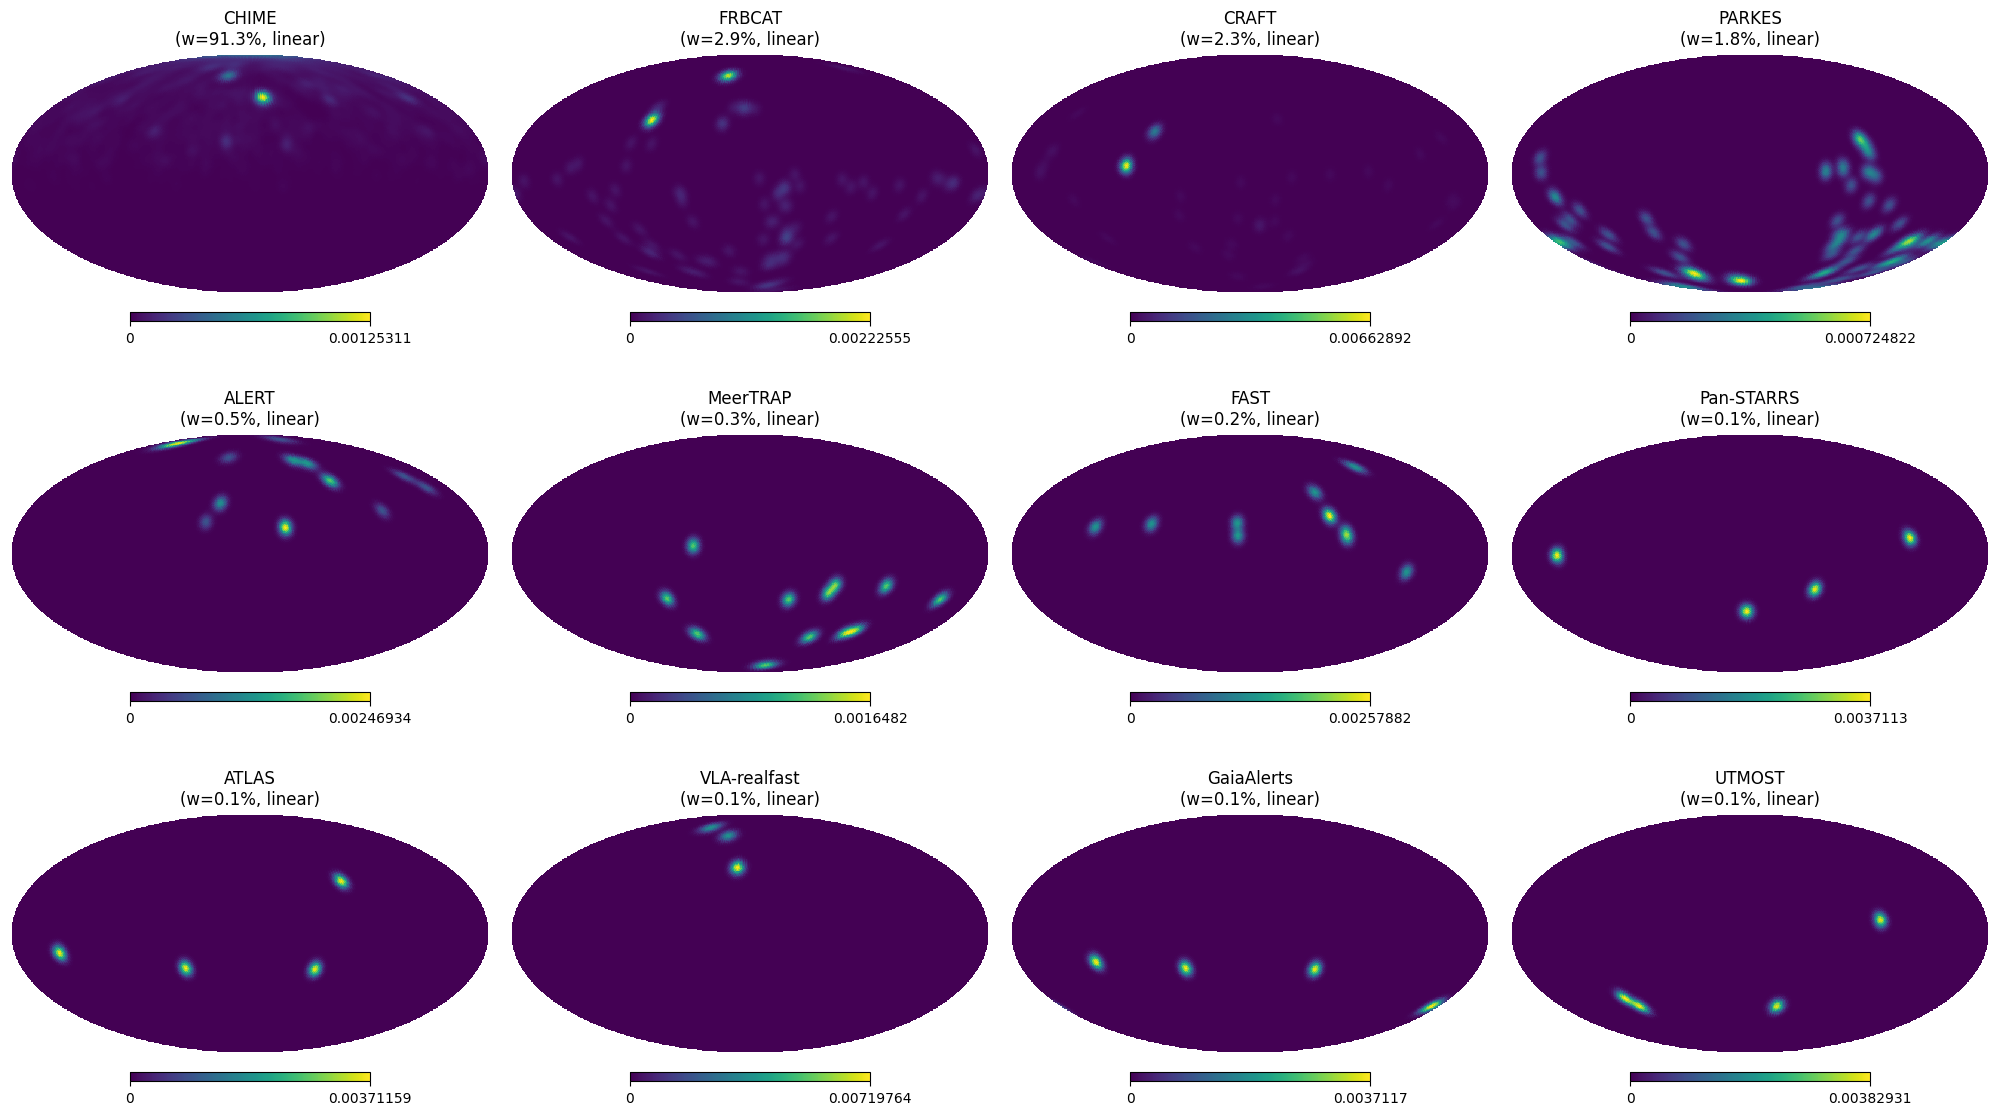

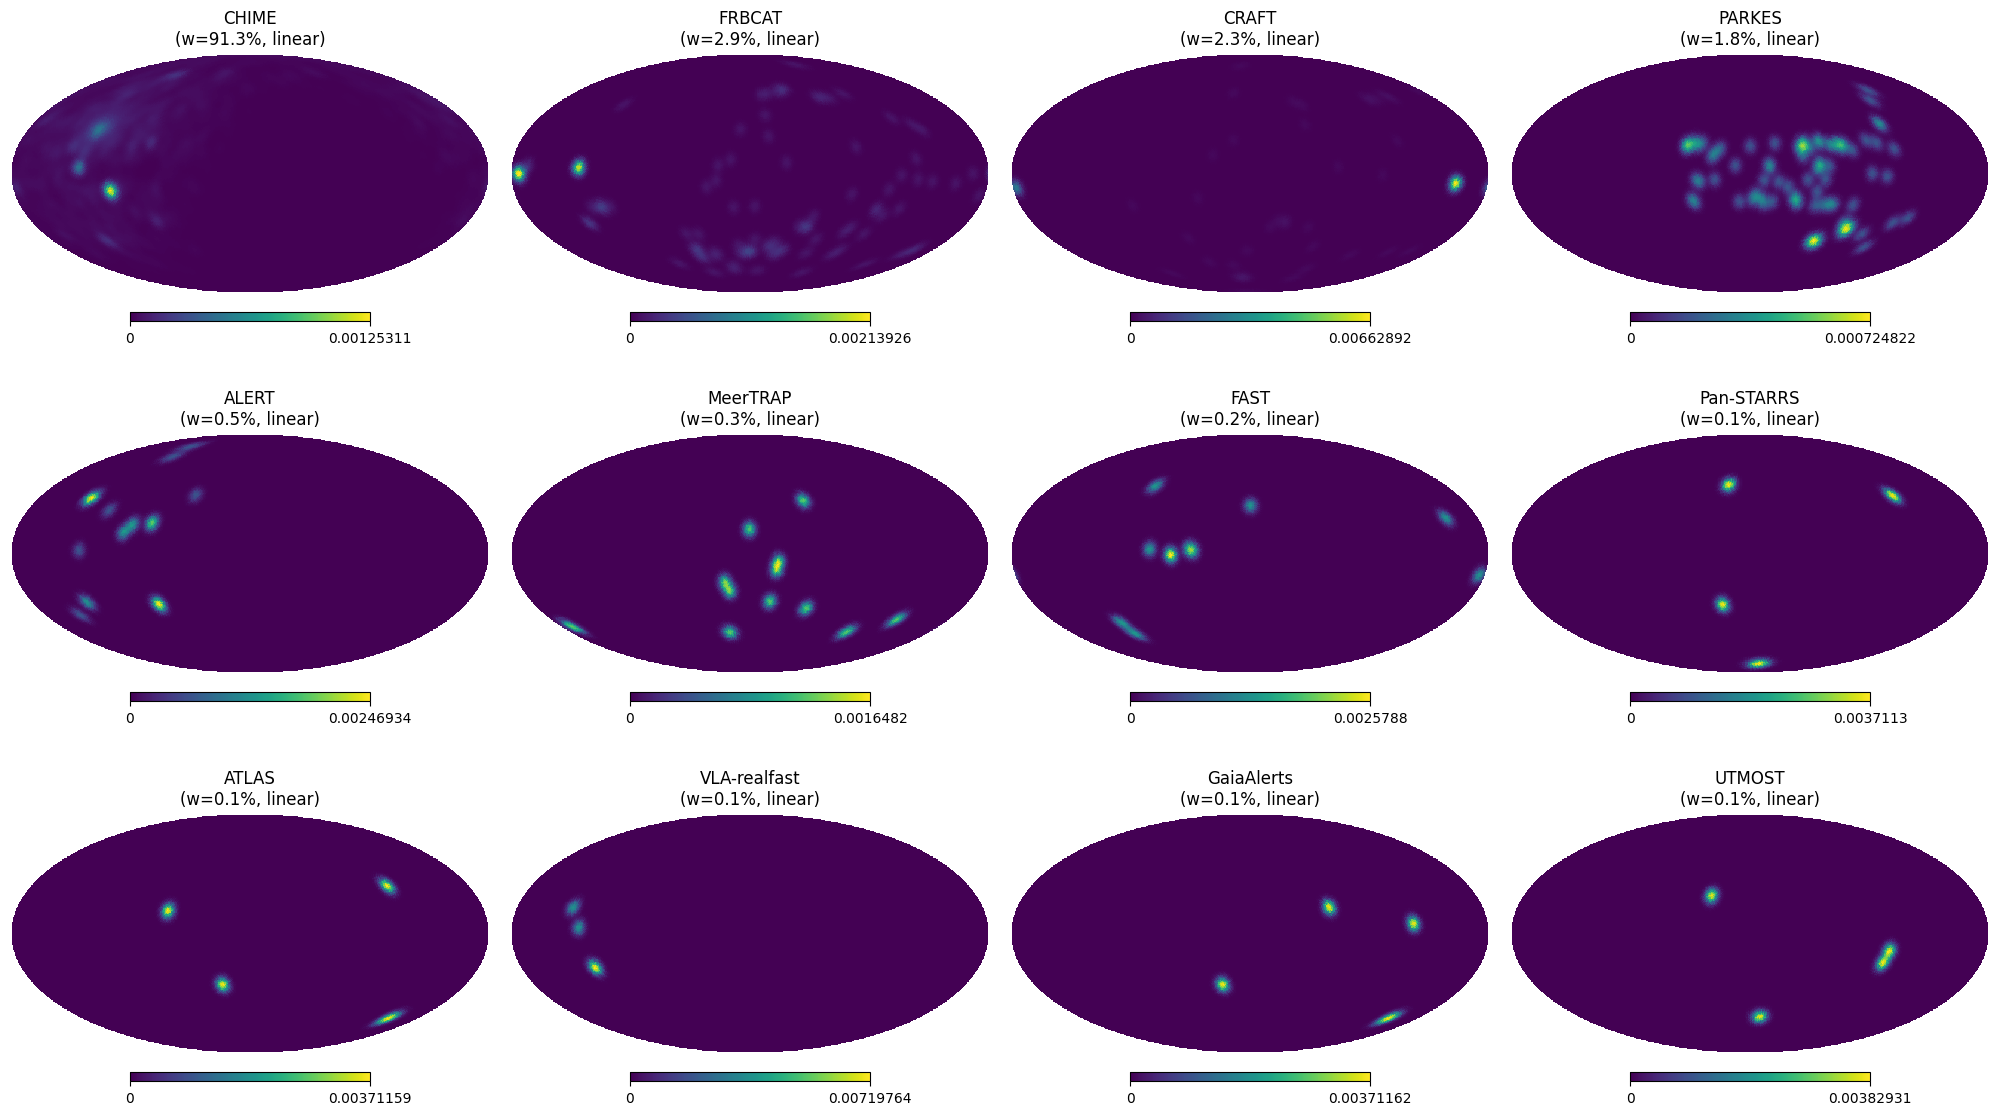


Selection-function maps saved:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/sf_validation_equatorial.png
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/sf_validation_galactic.png


In [7]:
# ==========================================================
# Selection-function validation
# ==========================================================

sf_validation = None

if RUN_CONFIG.use_sel_func:

    validator = (
        iso.SelectionFunctionValidator(
            context=context,
            sf_set=selection_functions,
        )
    )

    sf_validation = (
        validator.check_coverage()
    )

    validator.plot_sf(

        save_prefix=(

            context.outputs.figures_dir
            / "sf_validation"
        ),
    )

else:

    print(
        "\nSelection-function validation skipped."
    )


--- Survey partitioning ---
Unique surveys: 21

Survey populations:
          CHIME | N=4093 |  91.36%
         FRBCAT | N= 132 |   2.95%
          CRAFT | N= 103 |   2.30%
         PARKES | N=  81 |   1.81%
          ALERT | N=  23 |   0.51%
       MeerTRAP | N=  12 |   0.27%
           FAST | N=  11 |   0.25%
     Pan-STARRS | N=   4 |   0.09%
          ATLAS | N=   4 |   0.09%
   VLA-realfast | N=   4 |   0.09%
     GaiaAlerts | N=   4 |   0.09%
         UTMOST | N=   4 |   0.09%
            ZTF | N=   1 |   0.02%
         ALeRCE | N=   1 |   0.02%
        Tianlai | N=   1 |   0.02%
         TRAPUM | N=   1 |   0.02%
          PALFA | N=   1 |   0.02%
     VLITE-Fast | N=   1 |   0.02%
          GBNCC | N=   1 |   0.02%
         MASTER | N=   1 |   0.02%
        ASAS-SN | N=   1 |   0.02%


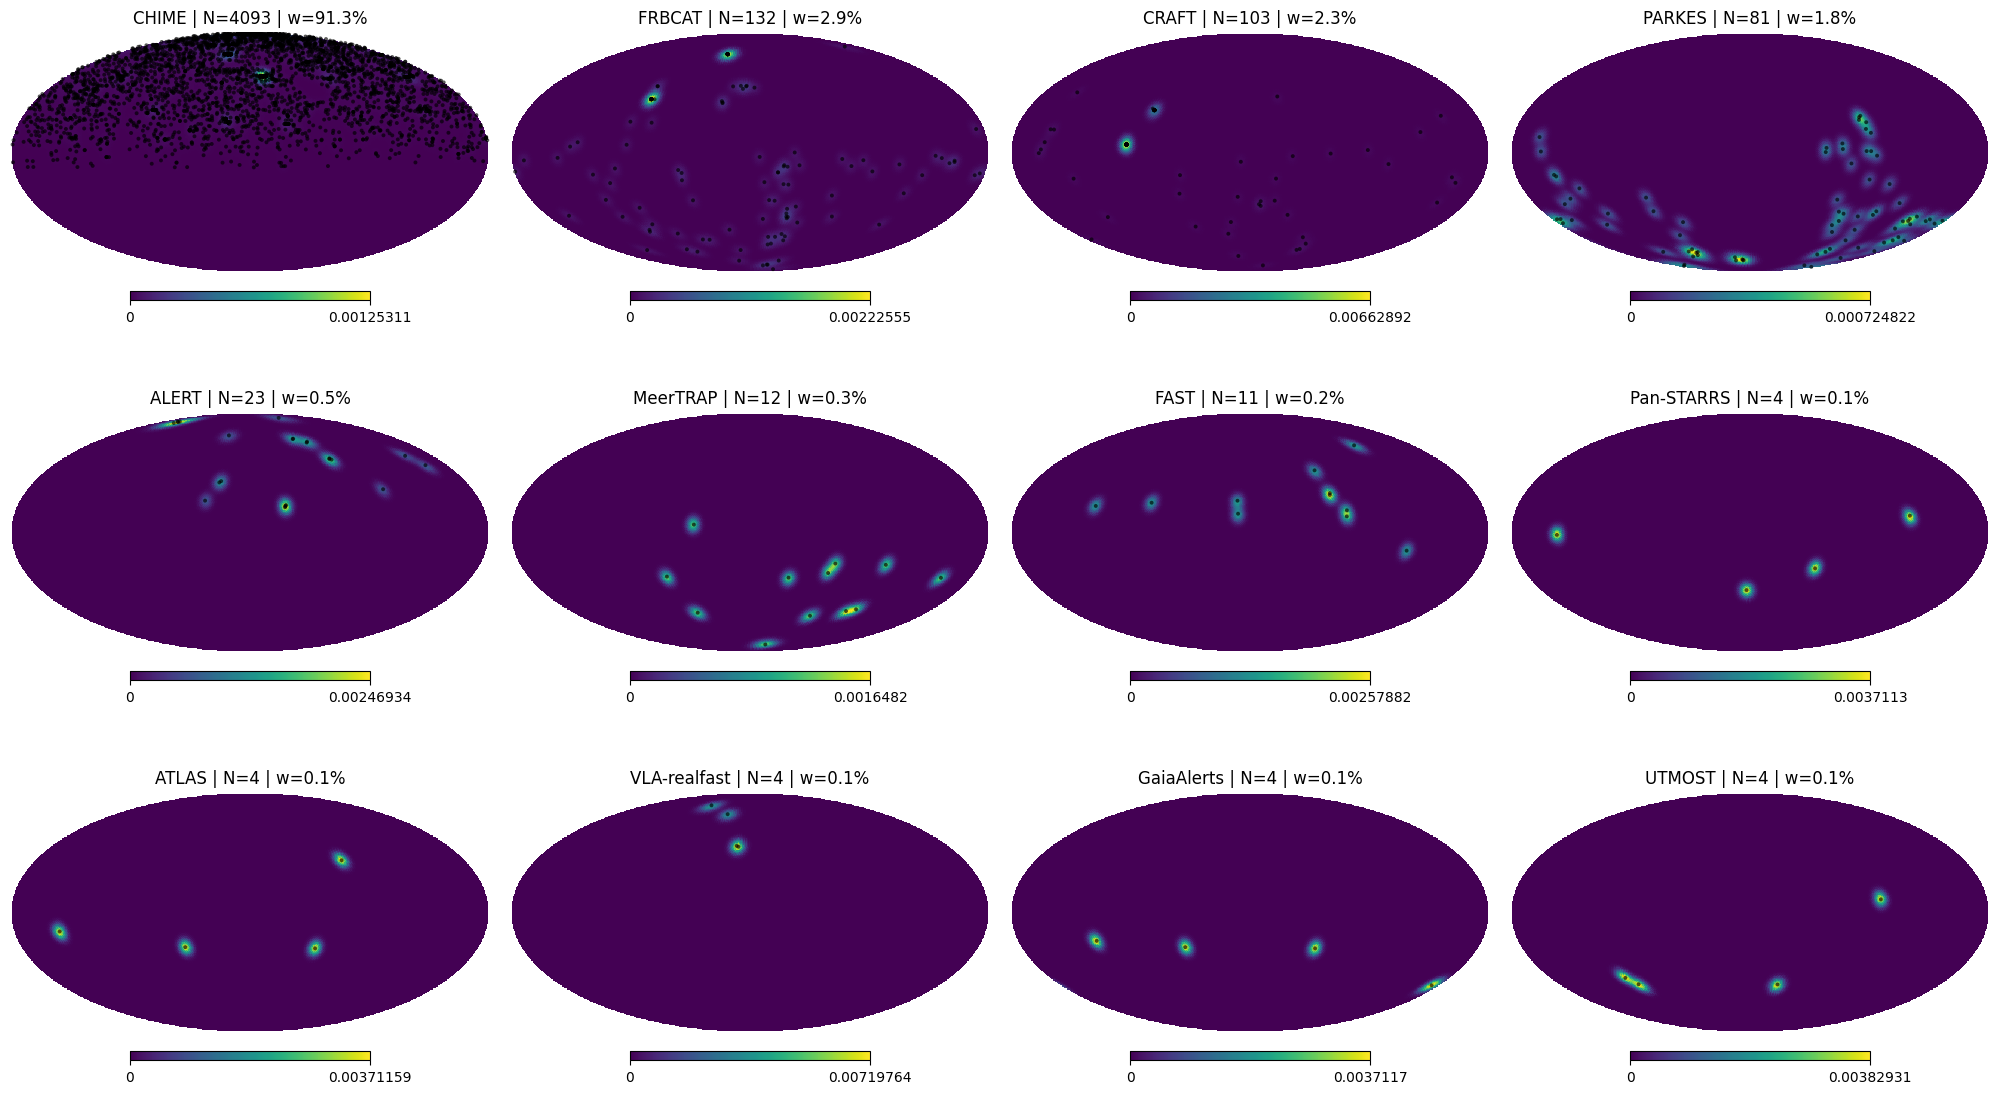

Saved survey maps: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/survey_maps_equatorial.png


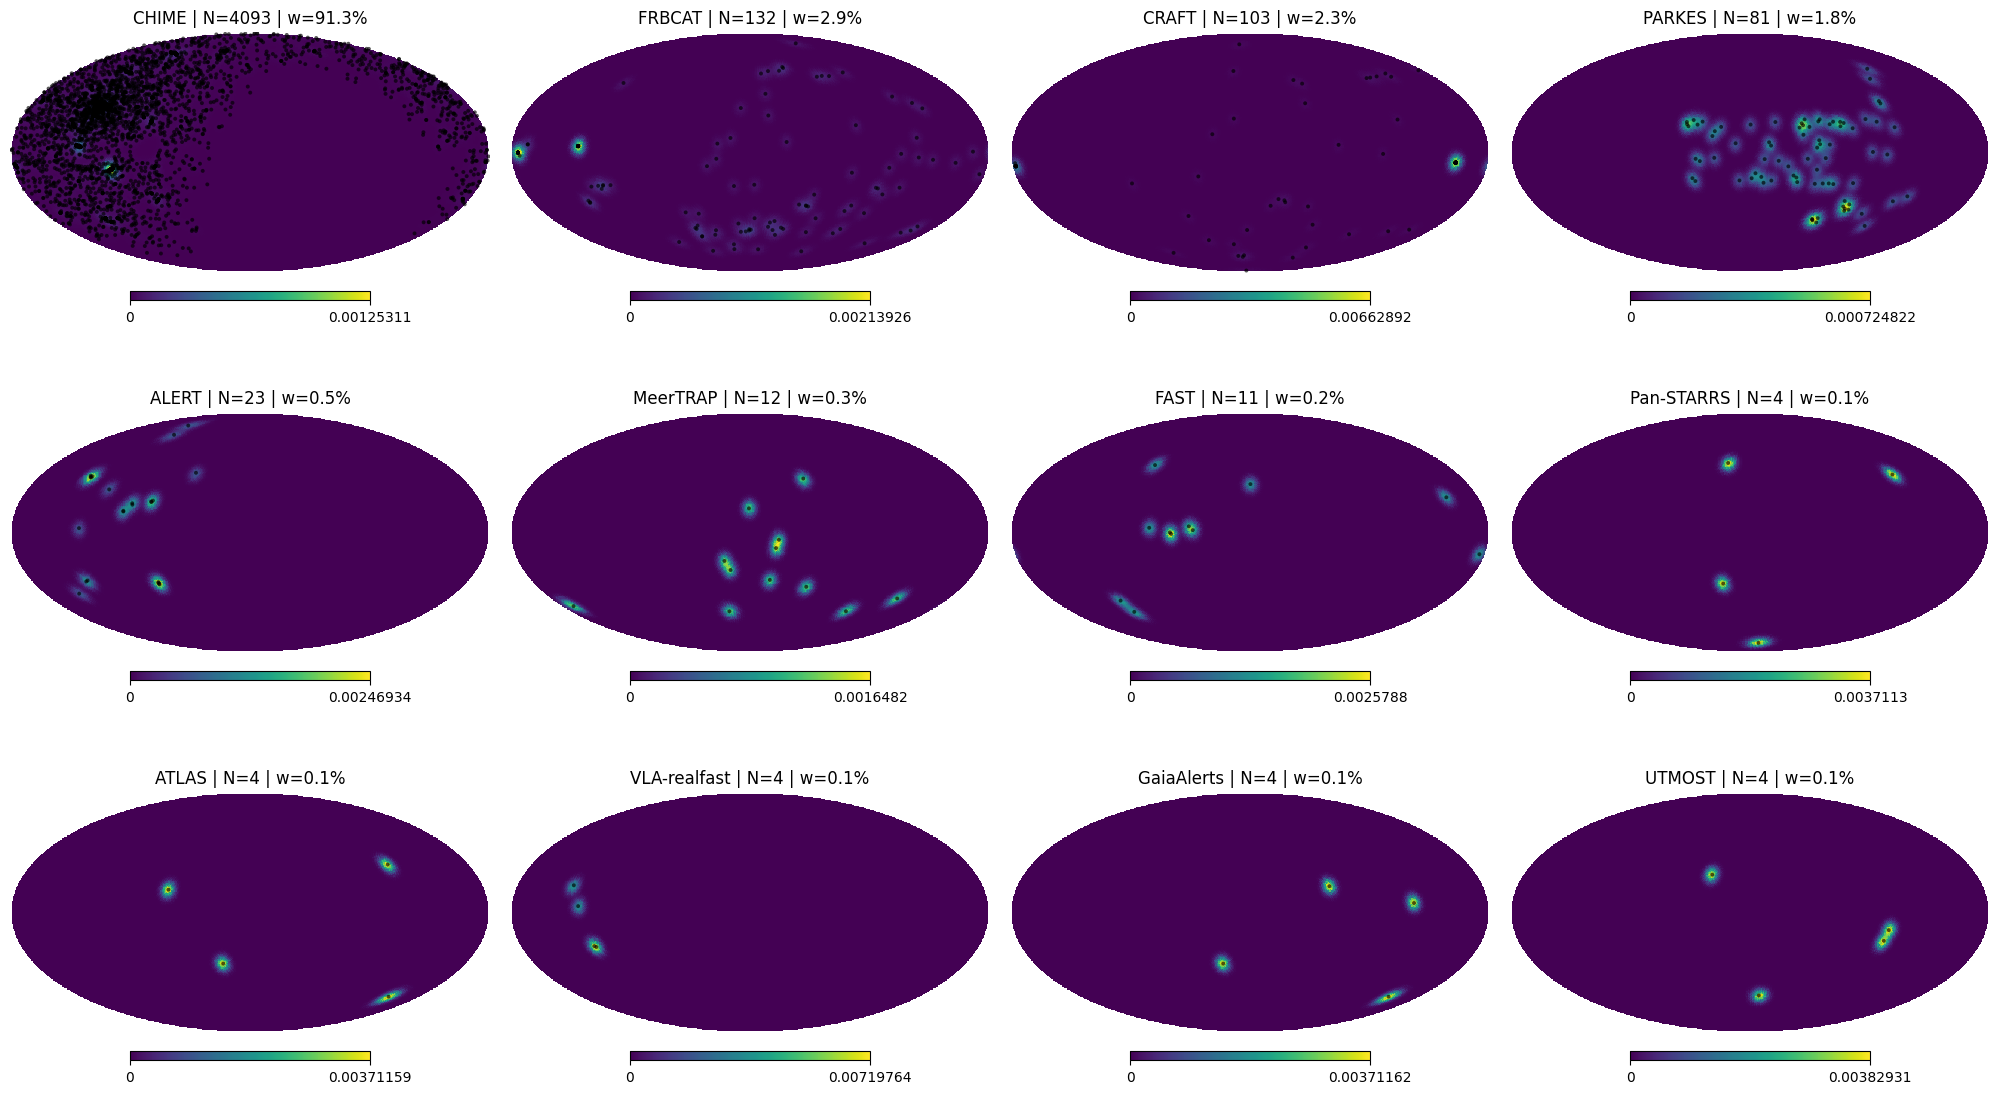

Saved survey maps: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/survey_maps_galactic.png


In [8]:
# ==========================================================
# Optional survey maps
# ==========================================================

survey_map_summary = None

if (
    RUN_TOP_SURVEY_MAPS
    and RUN_CONFIG.use_sel_func
):

    survey_map_summary = (
        iso.plot_top_survey_maps(

            context=context,

            df_data=df_data,

            sf_set=selection_functions,

            max_surveys=12,

            output_prefix=(
                context.outputs.figures_dir
                / "survey_maps"
            ),
        )
    )

else:

    print(
        "\nTop survey maps skipped."
    )

In [9]:
# ==========================================================
# Intersurvey diagnostics
# ==========================================================

print("\n==================================================")
print("INTERSURVEY DIAGNOSTICS")
print("==================================================")

surveys = iso.split_by_survey(
    context,
    df_data,
)

intersurvey = (
    iso.analyze_intersurvey_correlations(

        context,

        surveys,
    )
)

# ----------------------------------------------------------
# Convenience aliases
# ----------------------------------------------------------

corr_df = (
    intersurvey.correlation_matrix
)

overlap_df = (
    intersurvey.overlap_matrix
)


INTERSURVEY DIAGNOSTICS

--- Survey partitioning ---
Unique surveys: 21

Survey populations:
          CHIME | N=4093 |  91.36%
         FRBCAT | N= 132 |   2.95%
          CRAFT | N= 103 |   2.30%
         PARKES | N=  81 |   1.81%
          ALERT | N=  23 |   0.51%
       MeerTRAP | N=  12 |   0.27%
           FAST | N=  11 |   0.25%
     Pan-STARRS | N=   4 |   0.09%
          ATLAS | N=   4 |   0.09%
   VLA-realfast | N=   4 |   0.09%
     GaiaAlerts | N=   4 |   0.09%
         UTMOST | N=   4 |   0.09%
            ZTF | N=   1 |   0.02%
         ALeRCE | N=   1 |   0.02%
        Tianlai | N=   1 |   0.02%
         TRAPUM | N=   1 |   0.02%
          PALFA | N=   1 |   0.02%
     VLITE-Fast | N=   1 |   0.02%
          GBNCC | N=   1 |   0.02%
         MASTER | N=   1 |   0.02%
        ASAS-SN | N=   1 |   0.02%

INTERSURVEY CORRELATION ANALYSIS

Unique surveys: 21
HEALPix nside: 32
Overlap radius: 5.0 deg

--- Spatial correlation summary ---
Mean survey correlation: 0.0106
Max su

In [10]:
# ==========================================================
# Observed random catalog
# ==========================================================

print("\n==================================================")
print("OBSERVED RANDOM CATALOG")
print("==================================================")

rng_obs = np.random.default_rng(
    RUN_CONFIG.random_seed
)

df_rand_obs = (
    iso.generate_mixture_catalog_improved(

        context=context,

        n_observed=(
            len(df_data)
            * RUN_CONFIG.n_rand_factor
        ),

        sf_set=selection_functions,

        jitter_pixels=True,

        use_poisson=False,

        rng=rng_obs,
    )
)

print(
    f"Observed random catalog size = "
    f"{len(df_rand_obs)}"
)


OBSERVED RANDOM CATALOG
Observed random catalog size = 89600


In [11]:
# ==========================================================
# Observed angular statistics
# ==========================================================

print("\n==================================================")
print("OBSERVED ANGULAR STATISTICS")
print("==================================================")

theta, w_obs = iso.compute_2pacf(

    context=context,

    df_data=df_data,

    df_rand=df_rand_obs,
)

theta = np.asarray(
    theta,
    dtype=float,
)

w_obs = np.asarray(
    w_obs,
    dtype=float,
)

# ----------------------------------------------------------
# Numerical stabilization
# ----------------------------------------------------------

w_obs = np.nan_to_num(
    w_obs,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)

# ----------------------------------------------------------
# Absolute anisotropy statistic
# ----------------------------------------------------------

abs_obs = np.asarray(
    iso.get_absolute_sum(

        context=context,

        theta=theta,

        w=w_obs,
    ),
    dtype=float,
)

# ----------------------------------------------------------
# Diagnostics
# ----------------------------------------------------------

print(
    f"theta bins shape = "
    f"{theta.shape}"
)

print(
    f"w_obs shape = "
    f"{w_obs.shape}"
)

print(
    f"abs_obs shape = "
    f"{abs_obs.shape}"
)


OBSERVED ANGULAR STATISTICS
theta bins shape = (18,)
w_obs shape = (18,)
abs_obs shape = (9,)



JACKKNIFE UNCERTAINTIES

JACKKNIFE UNCERTAINTY ESTIMATION
RUN_TAG = weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3

--- Jackknife region assignment ---
NSIDE_JACKKNIFE = 4
Populated regions = 178

--- Jackknife region statistics ---
Objects per region:
min    = 1
median = 9.5
max    = 349


Jackknife regions:   0%|          | 0/178 [00:00<?, ?it/s]

  0%|          | 0/178 [00:00<?, ?it/s]


--- Jackknife summary ---
Leave-one-region samples = 178
Objects kept per sample:
min = 4131
max = 4479
Median sigma[w(theta)] = 2.3245e-02
Median sigma[|<w>|] = 2.9518e-02

--- Covariance correlation diagnostics ---
Mean off-diagonal corr: -0.0476
Median off-diagonal corr: -0.0260
95th percentile corr: 0.3088
Max off-diagonal corr: 0.5393


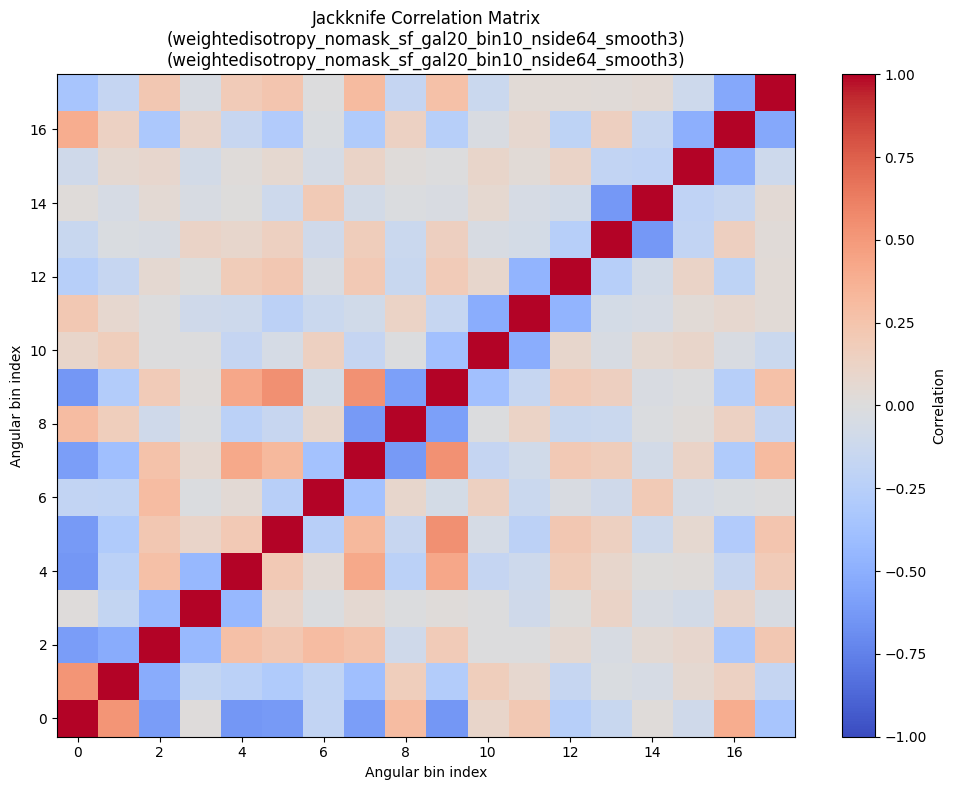


Saved correlation matrix:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/jackknife_correlation_matrix


In [12]:
# ==========================================================
# Jackknife uncertainties
# ==========================================================

print("\n==================================================")
print("JACKKNIFE UNCERTAINTIES")
print("==================================================")

jackknife = iso.run_jackknife_errors(

    context=context,

    df_data=df_data,

    sf_set=selection_functions,

    nside_jackknife=(
        RUN_CONFIG.nside_jackknife
    ),

    min_regions=(
        RUN_CONFIG.min_jackknife_regions
    ),
)


BOOTSTRAP UNCERTAINTIES

BOOTSTRAP UNCERTAINTY ESTIMATION
RUN_TAG = weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3

Bootstrap realizations = 500

Generating fixed random catalog...
Random catalog size = 89600


Bootstrap realizations:   0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


--- Bootstrap summary ---
Median sigma[w(theta)] = 3.9693e-03
Median sigma[|<w>|] = 5.0271e-03
Max sigma[w(theta)] = 2.0359e-02
Max sigma[|<w>|] = 2.4340e-02

--- Covariance correlation diagnostics ---
Mean off-diagonal corr: -0.0537
Median off-diagonal corr: -0.0098
95th percentile corr: 0.0729
Max off-diagonal corr: 0.1469


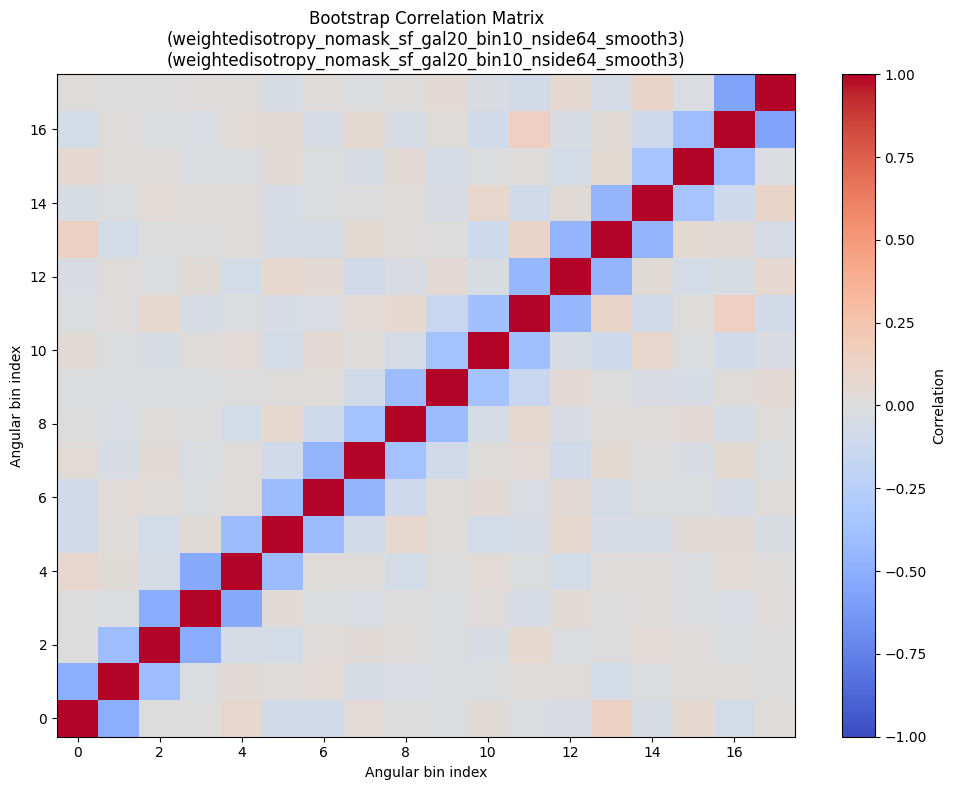


Saved correlation matrix:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/bootstrap_correlation_matrix


In [13]:
# ==========================================================
# Bootstrap uncertainties
# ==========================================================

print("\n==================================================")
print("BOOTSTRAP UNCERTAINTIES")
print("==================================================")

bootstrap = iso.run_bootstrap_errors(

    context=context,

    df_data=df_data,

    sf_set=selection_functions,

    n_bootstrap=(
        RUN_CONFIG.n_bootstrap
    ),

    n_jobs=RUN_CONFIG.n_jobs,
)

In [14]:
# ==========================================================
# H0 mock ensemble
# ==========================================================

print("\n==================================================")
print("H0 ENSEMBLE")
print("==================================================")

mock_ensemble = (
    iso.run_ensemble_mocks(

        context=context,

        df_data=df_data,

        sf_set=(
            selection_functions
            if RUN_CONFIG.use_sel_func
            else None
        ),

        n_ensemble=(
            RUN_CONFIG.n_ensemble
        ),

        n_mocks_per=(
            RUN_CONFIG.n_mocks_per_ensemble
        ),

        perturbation_scale=(
            RUN_CONFIG.perturbation_scale
        ),

        n_rand_factor=(
            RUN_CONFIG.n_rand_factor
        ),

        n_jobs=RUN_CONFIG.n_jobs,
    )
)

# ----------------------------------------------------------
# Convenience aliases
# ----------------------------------------------------------

all_w_h0 = np.asarray(
    mock_ensemble.w_theta,
    dtype=float,
)

all_abs_h0 = np.asarray(
    mock_ensemble.abs_statistics,
    dtype=float,
)

print(
    f"all_w_h0 shape = "
    f"{all_w_h0.shape}"
)

print(
    f"all_abs_h0 shape = "
    f"{all_abs_h0.shape}"
)


H0 ENSEMBLE

--- Generating H0 ensemble mocks (with selection functions) ---
Total H0 mocks: 1000


H0 ensemble mocks:   0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]


Generated mocks:
  w(theta): (1000, 18)
  |<w>| tomography: (1000, 9)
all_w_h0 shape = (1000, 18)
all_abs_h0 shape = (1000, 9)


In [15]:
# ==========================================================
# Remove invalid H0 realizations
# ==========================================================

valid_h0 = (

    np.all(
        np.isfinite(all_w_h0),
        axis=1,
    )

    &

    np.all(
        np.isfinite(all_abs_h0),
        axis=1,
    )
)

if not np.all(valid_h0):

    n_removed = int(
        np.sum(~valid_h0)
    )

    print(
        f"\nWARNING: removing "
        f"{n_removed} invalid H0 mocks."
    )

    all_w_h0 = all_w_h0[
        valid_h0
    ]

    all_abs_h0 = all_abs_h0[
        valid_h0
    ]

print(
    f"all_w_h0 shape = "
    f"{all_w_h0.shape}"
)

print(
    f"all_abs_h0 shape = "
    f"{all_abs_h0.shape}"
)

all_w_h0 shape = (1000, 18)
all_abs_h0 shape = (1000, 9)



STATISTICAL INFERENCE

GLOBAL ISOTROPY INFERENCE
RUN_TAG = weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3
USE_GAL_MASK = False
USE_SEL_FUNC = True

Max |H0 mean| = 3.5774e-04

--- Covariance correlation diagnostics ---
Mean off-diagonal corr: -0.0511
Median off-diagonal corr: -0.0470
95th percentile corr: 0.0241
Max off-diagonal corr: 0.0557


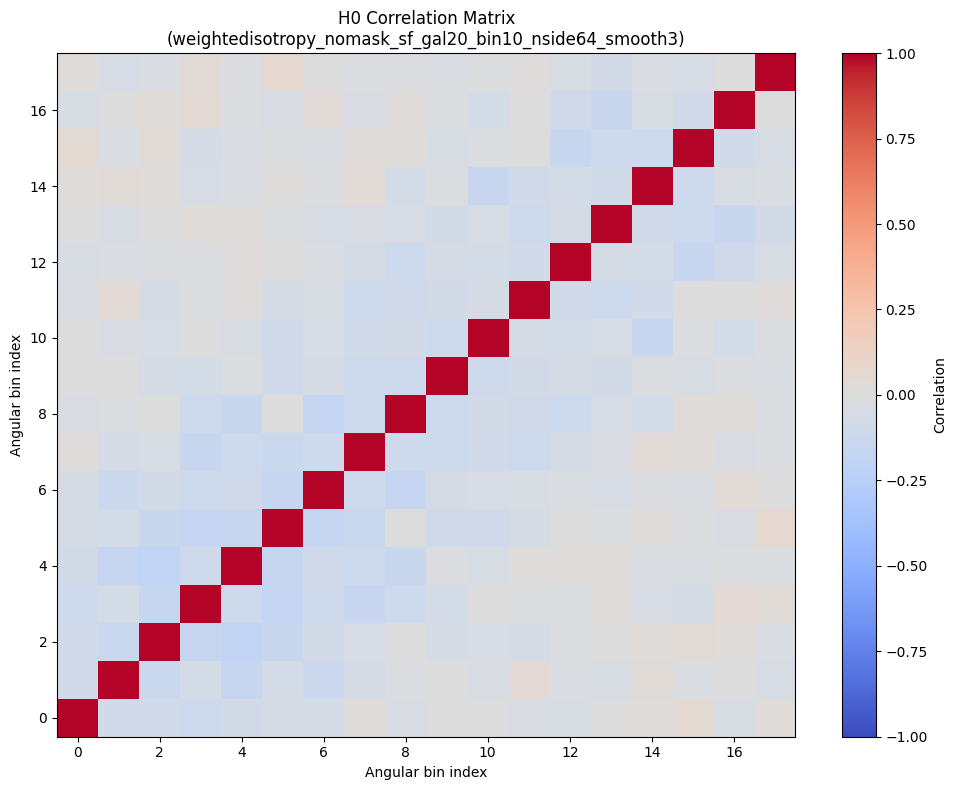


Saved correlation matrix:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/h0_correlation_matrix.png

MOCK SIMILARITY DIAGNOSTICS
Mocks analyzed: 100
Mean off-diagonal corr: -0.0090
Median off-diagonal corr: -0.0100
95th percentile corr: 0.4034
99th percentile corr: 0.5381
Max off-diagonal corr: 0.7665

Interpretation:
  ⚠ Strong mock correlations detected.
  Covariance estimation may be biased.


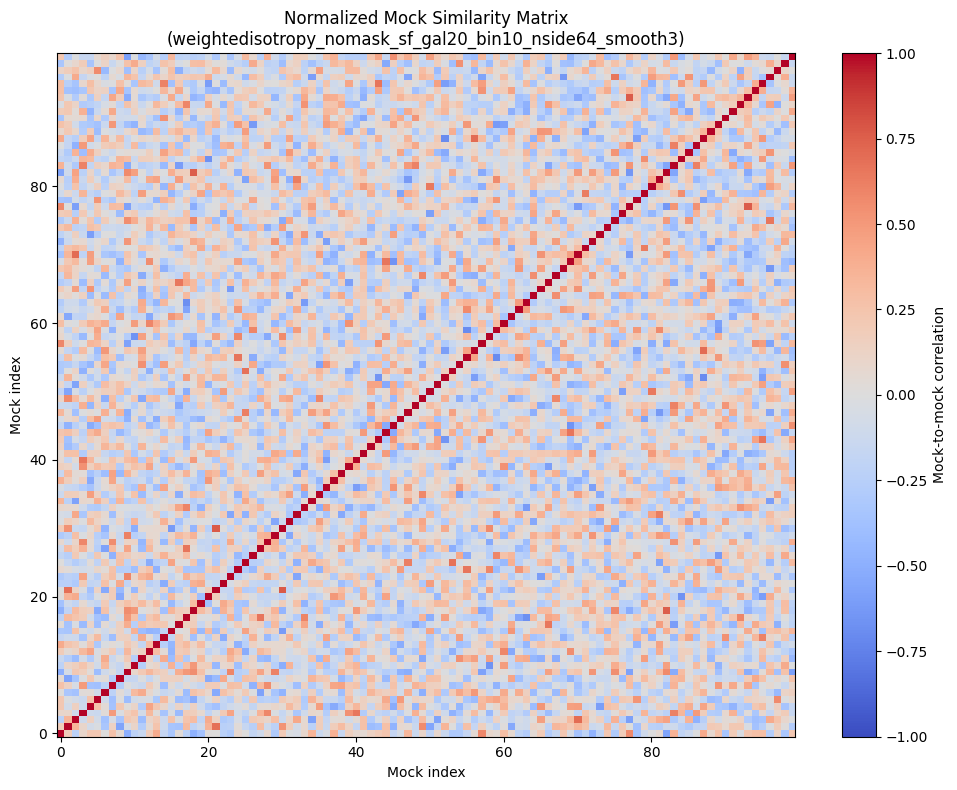


Saved mock similarity matrix:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/h0_mock_similarity.png


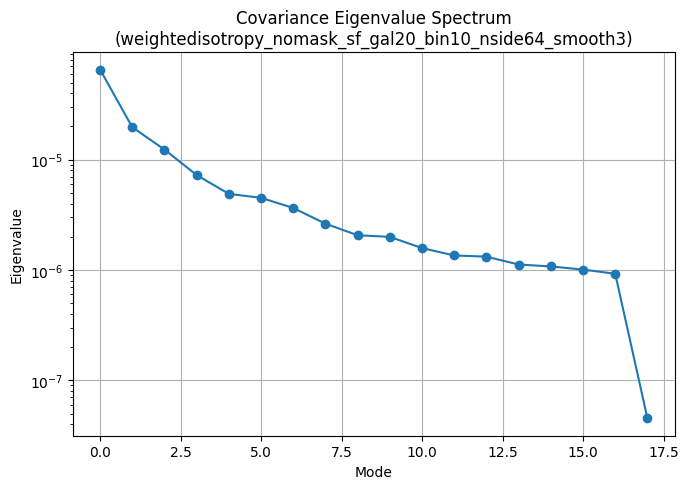


Effective number of modes = 3.56

--- SVD covariance regularization ---
Modes kept: 17/18
Eigenvalue threshold: 1.00e-02
Explained variance kept: 99.97%
SVD condition number: 7.09e+01

--- Full covariance diagnostic (FRB isotropy (weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3)) ---
Chi2 = 252.435
Chi2/dof = 14.849
p-value (Chi2 analytic) = 6.6377e-44
p-value (Chi2 empirical) = 9.9900e-04
p-value (Chi2 empirical) is at the Monte Carlo floor: p <= 9.9900e-04
Sigma-equivalent (from empirical p) = 3.09

--- Primary isotropy statistic (SVD-regularized) ---
Eigenvalue cut = 1.0e-02
SVD modes kept = 17/18
Chi2 SVD = 252.367
Chi2 SVD/dof = 14.845
p-value SVD (Chi2 analytic) = 6.8536e-44
p-value SVD (empirical) = 9.9900e-04
Sigma-equivalent SVD (from empirical p) = 3.09

--- Covariance diagnostics ---
Mocks = 1000
Bins = 18
Covariance rank = 18/18
Covariance condition number = 1.4447e+03
SVD retained condition number = 7.0859e+01
Effective modes = 3.56
RMS normalized deviation = 3.826

In [16]:
# ==========================================================
# Statistical inference
# ==========================================================

print("\n==================================================")
print("STATISTICAL INFERENCE")
print("==================================================")

stats = iso.compute_statistics(

    context=context,

    w_obs=w_obs,

    abs_obs=abs_obs,

    all_w_h0=all_w_h0,

    all_abs_h0=all_abs_h0,
)


MAIN VISUALIZATIONS


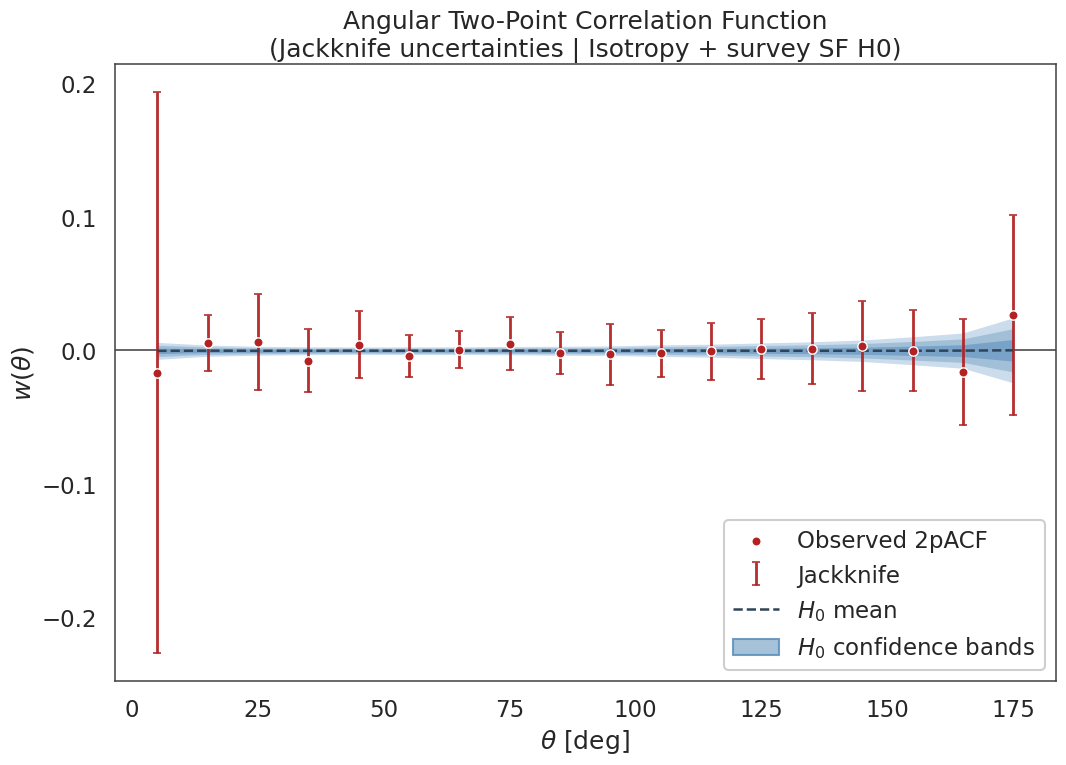

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/2pacf_jackknife.png


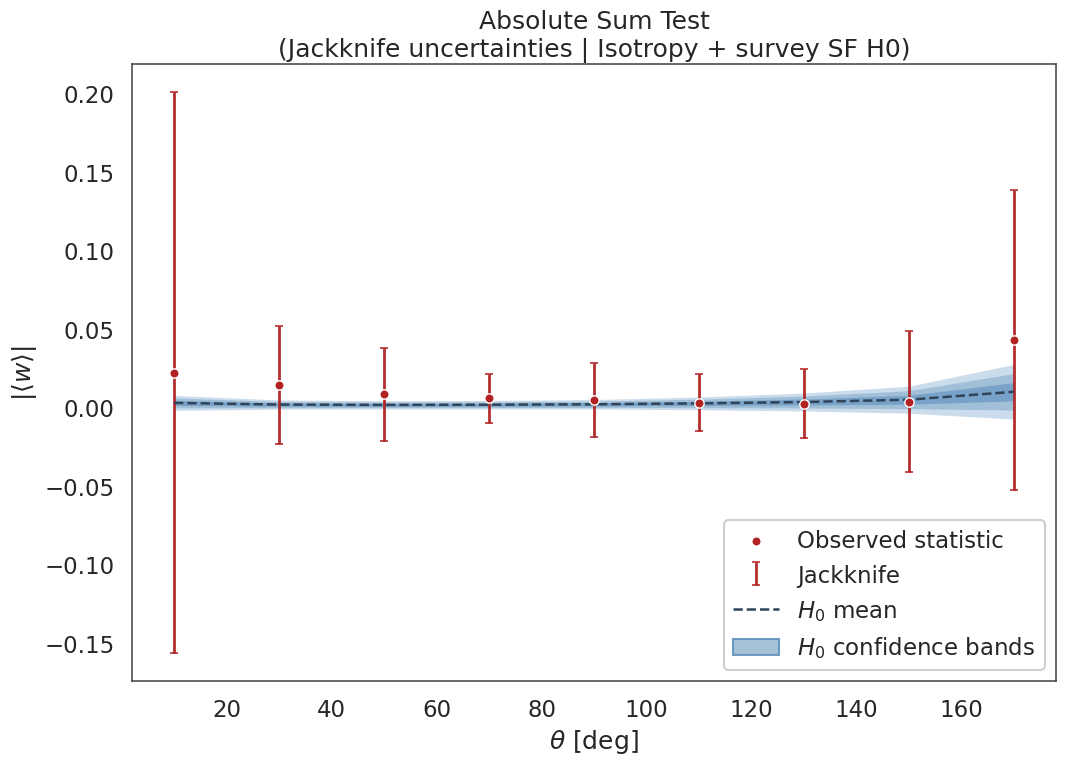

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/absolute_anisotropy_jackknife.png


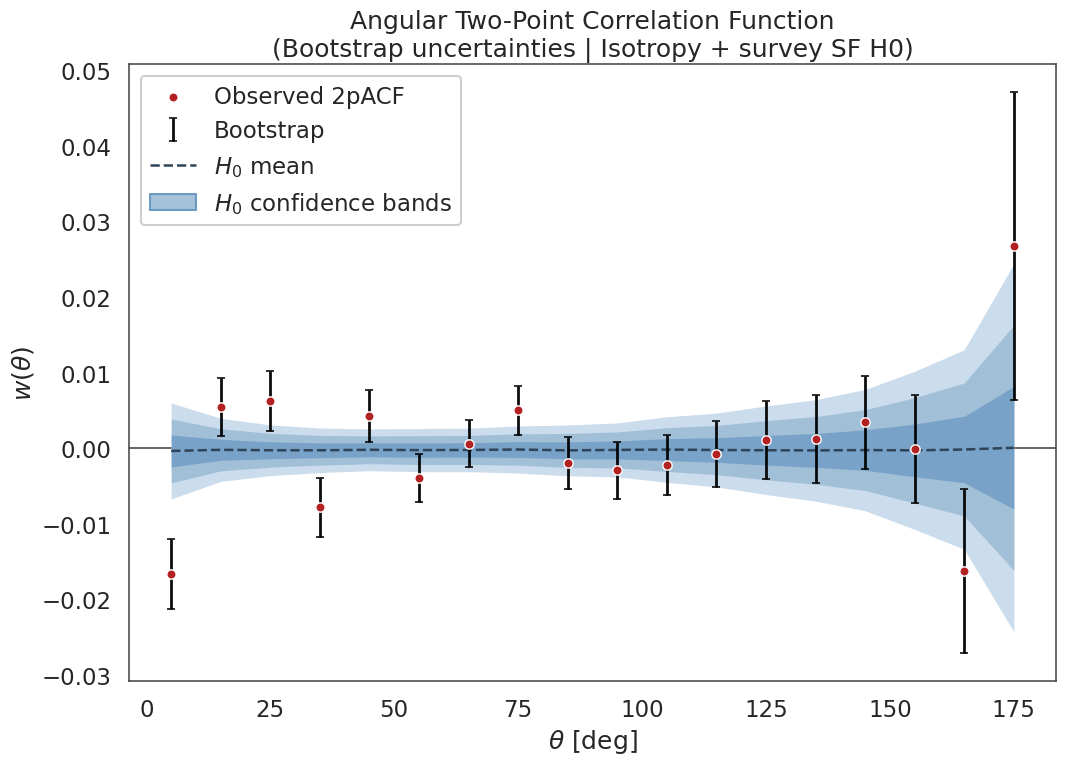

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/2pacf_bootstrap.png


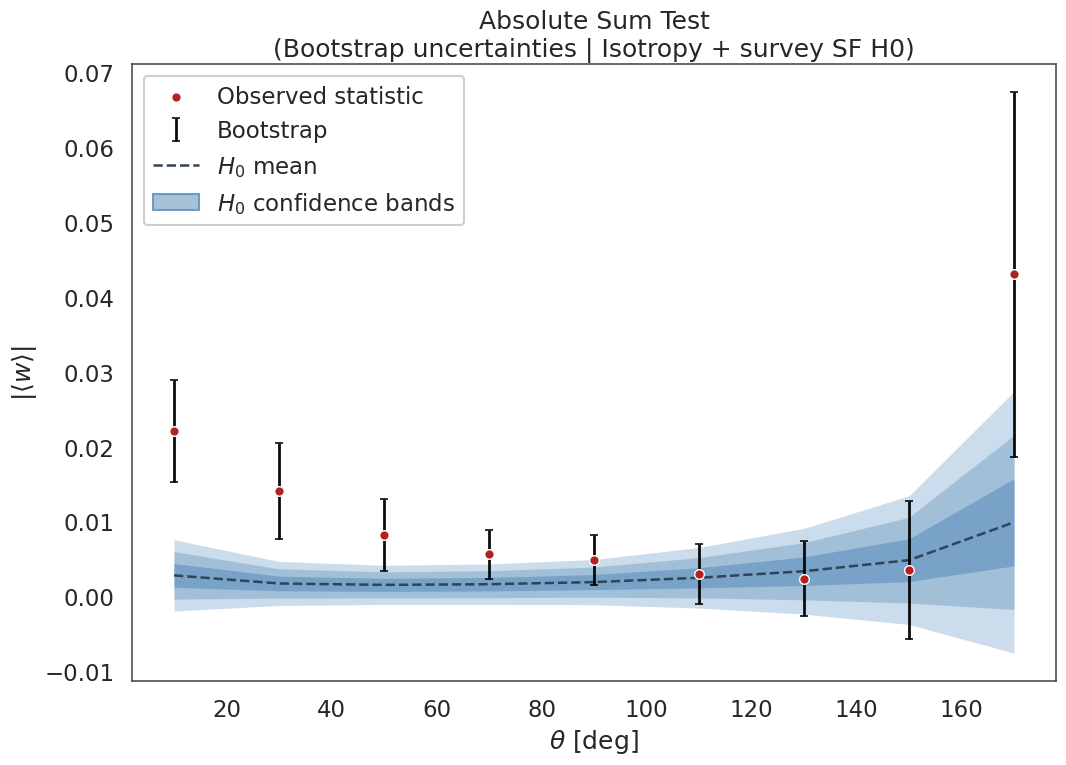

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/absolute_anisotropy_bootstrap.png


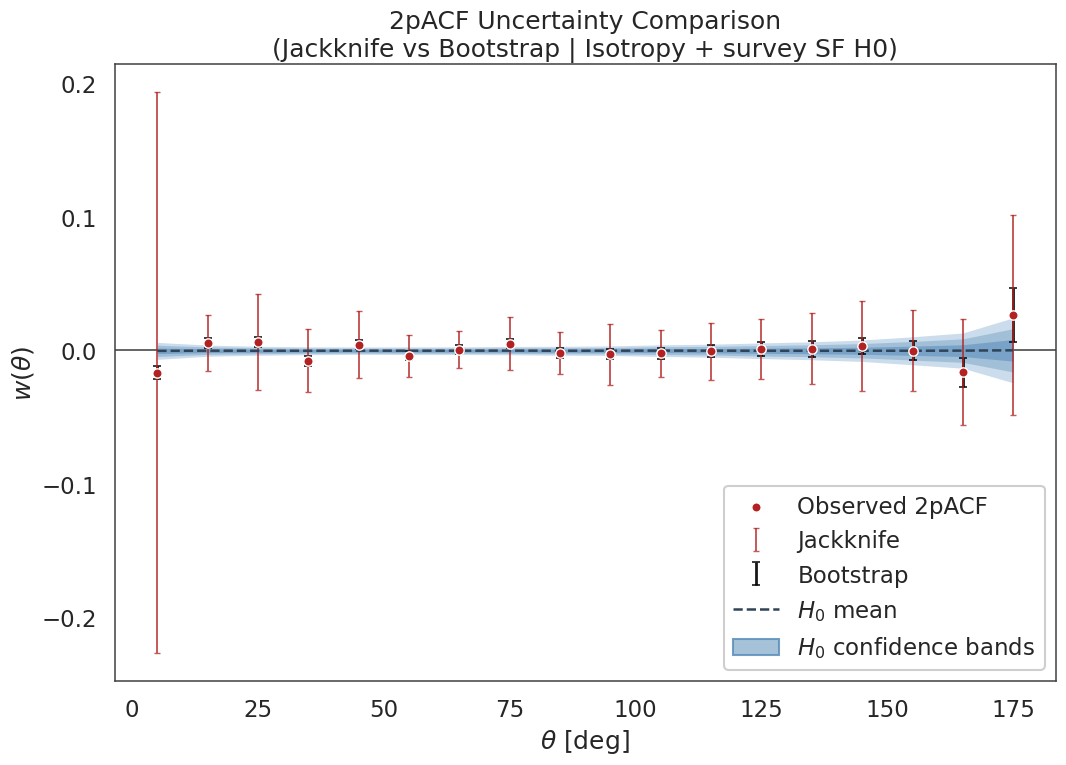

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/2pacf_jk_vs_bootstrap.png


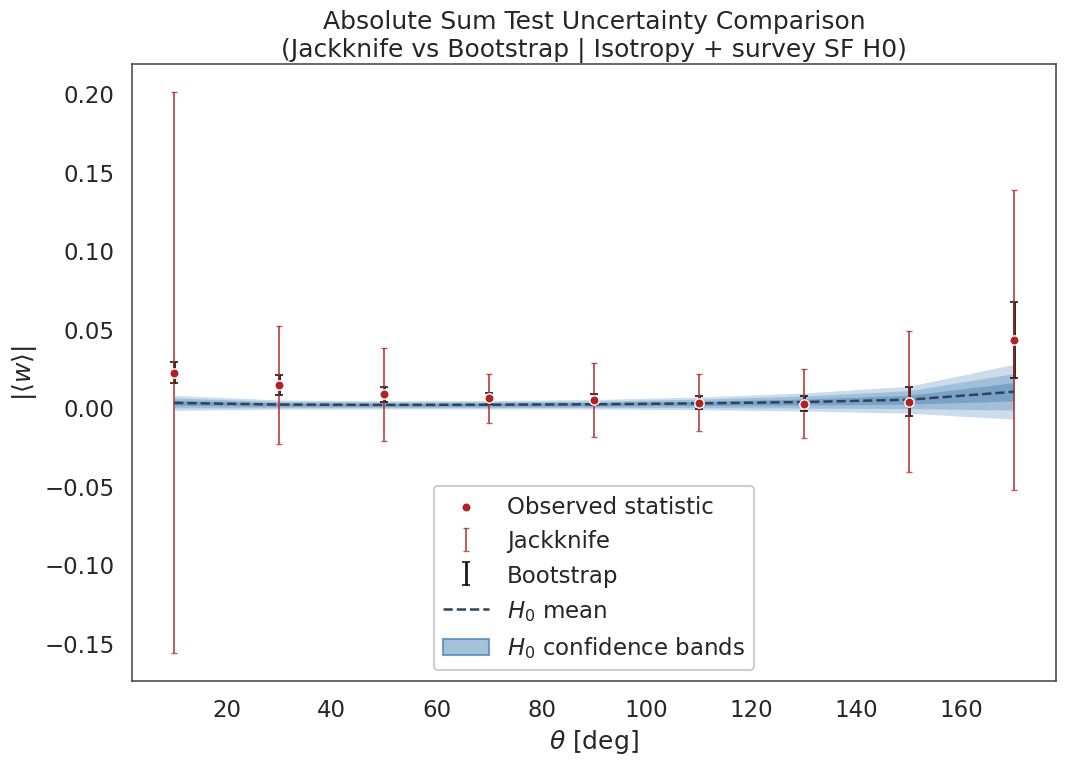

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/figures/absolute_anisotropy_jk_vs_bootstrap.png


In [17]:
# ==========================================================
# Main visualizations
# ==========================================================

print("\n==================================================")
print("MAIN VISUALIZATIONS")
print("==================================================")

# ==========================================================
# Jackknife plots
# ==========================================================

iso.plot_results_with_jackknife(

    context=context,

    theta=theta,

    w_obs=w_obs,

    abs_obs=abs_obs,

    all_w_h0=all_w_h0,

    all_abs_h0=all_abs_h0,

    jackknife=jackknife,

    output_2pacf=(

        context.outputs.figures_dir
        / "2pacf_jackknife.png"
    ),

    output_abs=(

        context.outputs.figures_dir
        / "absolute_anisotropy_jackknife.png"
    ),
)

# ==========================================================
# Bootstrap plots
# ==========================================================

iso.plot_results_with_bootstrap(

    context=context,

    theta=theta,

    w_obs=w_obs,

    abs_obs=abs_obs,

    all_w_h0=all_w_h0,

    all_abs_h0=all_abs_h0,

    bootstrap=bootstrap,

    output_2pacf=(

        context.outputs.figures_dir
        / "2pacf_bootstrap.png"
    ),

    output_abs=(

        context.outputs.figures_dir
        / "absolute_anisotropy_bootstrap.png"
    ),
)

# ==========================================================
# JK vs Bootstrap comparison
# ==========================================================

iso.plot_results_jk_vs_bootstrap(

    context=context,

    theta=theta,

    w_obs=w_obs,

    abs_obs=abs_obs,

    all_w_h0=all_w_h0,

    all_abs_h0=all_abs_h0,

    jackknife=jackknife,

    bootstrap=bootstrap,

    output_2pacf=(

        context.outputs.figures_dir
        / "2pacf_jk_vs_bootstrap.png"
    ),

    output_abs=(

        context.outputs.figures_dir
        / "absolute_anisotropy_jk_vs_bootstrap.png"
    ),
)

In [18]:
# ==========================================================
# Chi-square diagnostics
# ==========================================================

print("\n==================================================")
print("CHI-SQUARE DIAGNOSTICS")
print("==================================================")

(
    chi2_bin_diagnostics,
    svd_mode_contributions,
) = iso.compute_chi2_diagnostic_tables(

    context=context,

    theta=theta,

    w_obs=w_obs,

    all_w_h0=all_w_h0,

    eigenvalue_cut=(
        RUN_CONFIG.svd_eigenvalue_cut
    ),
)


CHI-SQUARE DIAGNOSTICS

CHI-SQUARE DIAGNOSTICS

Run tag: weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3

Mocks: 1000
Bins: 18
Hartlap factor: 0.98098
SVD modes kept: 17 / 18
Eigenvalue cut: 1.000e-02
Stable covariance condition number: 1.445e+03
Largest eigenvalue: 6.550e-05
Smallest retained eigenvalue: 4.534e-08


In [19]:
# ==========================================================
# Assemble results dictionary
# ==========================================================

results = {

    # ------------------------------------------------------
    # Runtime
    # ------------------------------------------------------

    "context":
        context,

    "config":
        RUN_CONFIG,

    # ------------------------------------------------------
    # Observed catalog
    # ------------------------------------------------------

    "df_data":
        df_data,

    # ------------------------------------------------------
    # Angular statistics
    # ------------------------------------------------------

    "theta":
        theta,

    "w_obs":
        w_obs,

    "abs_obs":
        abs_obs,

    # ------------------------------------------------------
    # Selection functions
    # ------------------------------------------------------

    "selection_functions":
        selection_functions,

    "sf_validation":
        sf_validation,

    "survey_map_summary":
        survey_map_summary,

    # ------------------------------------------------------
    # Intersurvey analysis
    # ------------------------------------------------------

    "corr_df":
        corr_df,

    "overlap_df":
        overlap_df,

    # ------------------------------------------------------
    # Resampling uncertainties
    # ------------------------------------------------------

    "jackknife":
        jackknife,

    "bootstrap":
        bootstrap,

    # ------------------------------------------------------
    # H0 ensemble
    # ------------------------------------------------------

    "all_w_h0":
        all_w_h0,

    "all_abs_h0":
        all_abs_h0,

    # ------------------------------------------------------
    # Statistical inference
    # ------------------------------------------------------

    "stats":
        stats,

    # ------------------------------------------------------
    # Chi-square diagnostics
    # ------------------------------------------------------

    "chi2_bin_diagnostics":
        chi2_bin_diagnostics,

    "svd_mode_contributions":
        svd_mode_contributions,

    # ------------------------------------------------------
    # Cached covariance products
    # ------------------------------------------------------

    "covariance_matrix":
        getattr(
            context,
            "last_covariance_matrix",
            None,
        ),
}

print("\nAvailable result keys:")

print(
    sorted(results.keys())
)


Available result keys:
['abs_obs', 'all_abs_h0', 'all_w_h0', 'bootstrap', 'chi2_bin_diagnostics', 'config', 'context', 'corr_df', 'covariance_matrix', 'df_data', 'jackknife', 'overlap_df', 'selection_functions', 'sf_validation', 'stats', 'survey_map_summary', 'svd_mode_contributions', 'theta', 'w_obs']


In [20]:
# ==========================================================
# Save exported tables and report
# ==========================================================

saved_tables = None

if SAVE_OUTPUTS:

    print("\n==================================================")
    print("EXPORT OUTPUTS")
    print("==================================================")

    saved_tables = iso.save_tables(

        context=context,

        results=results,

        prefix=RUN_CONFIG.run_tag,
    )

else:

    print(
        "Output export skipped because "
        "SAVE_OUTPUTS=False."
    )


EXPORT OUTPUTS

CHI-SQUARE DIAGNOSTICS

Run tag: weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3

Mocks: 1000
Bins: 18
Hartlap factor: 0.98098
SVD modes kept: 17 / 18
Eigenvalue cut: 1.000e-02
Stable covariance condition number: 1.445e+03
Largest eigenvalue: 6.550e-05
Smallest retained eigenvalue: 4.534e-08

Saved report: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/report/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3_summary.md

--- Saved analysis tables ---
sf_validation: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/tables/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3_sf_validation.csv
intersurvey_corr: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/Main/outputs/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3/tables/weightedisotropy_nomask_sf_gal20_bin10_nside64_smooth3_intersurvey_corr.csv
intersur

In [21]:
# ==========================================================
# Useful summaries
# ==========================================================

print("\n==================================================")
print("SUMMARY")
print("==================================================")

# ----------------------------------------------------------
# Main statistics
# ----------------------------------------------------------

print(stats)

# ----------------------------------------------------------
# Jackknife
# ----------------------------------------------------------

print(
    "\nMedian jackknife sigma w(theta):"
)

print(
    np.median(
        jackknife.w_err
    )
)

print(
    "\nMedian jackknife sigma |<w>|:"
)

print(
    np.median(
        jackknife.abs_err
    )
)

# ----------------------------------------------------------
# Bootstrap
# ----------------------------------------------------------

print(
    "\nMedian bootstrap sigma w(theta):"
)

print(
    np.median(
        bootstrap.w_err
    )
)

print(
    "\nMedian bootstrap sigma |<w>|:"
)

print(
    np.median(
        bootstrap.abs_err
    )
)

# ----------------------------------------------------------
# Selection-function validation
# ----------------------------------------------------------

print("\nSF validation:")

print(
    results.get(
        "sf_validation",
        None,
    )
)

# ----------------------------------------------------------
# Intersurvey diagnostics
# ----------------------------------------------------------

print("\nIntersurvey correlation:")

print(
    results.get(
        "corr_df",
        None,
    )
)

print("\nIntersurvey overlap:")

print(
    results.get(
        "overlap_df",
        None,
    )
)

# ----------------------------------------------------------
# Jackknife covariance diagnostics
# ----------------------------------------------------------

print(
    "\nJackknife W covariance shape:"
)

print(
    results["jackknife"]
    .w_cov.shape
)

print(
    "\nJackknife absolute covariance shape:"
)

print(
    results["jackknife"]
    .abs_cov.shape
)

# ----------------------------------------------------------
# Bootstrap covariance diagnostics
# ----------------------------------------------------------

print(
    "\nBootstrap W covariance shape:"
)

print(
    results["bootstrap"]
    .w_cov.shape
)

print(
    "\nBootstrap absolute covariance shape:"
)

print(
    results["bootstrap"]
    .abs_cov.shape
)

# ----------------------------------------------------------
# H0 ensemble diagnostics
# ----------------------------------------------------------

print(
    "\nH0 w(theta) ensemble shape:"
)

print(
    results["all_w_h0"].shape
)

print(
    "\nH0 |<w>| ensemble shape:"
)

print(
    results["all_abs_h0"].shape
)

# ----------------------------------------------------------
# Chi-square diagnostics
# ----------------------------------------------------------

print(
    "\nChi-square diagnostic table shape:"
)

print(
    results[
        "chi2_bin_diagnostics"
    ].shape
)

print(
    "\nSVD mode contribution table shape:"
)

print(
    results[
        "svd_mode_contributions"
    ].shape
)


SUMMARY
TestStatistics(chi2=ChiSquareStatistics(chi2=252.4349803268986, chi2_red=14.849116489817565, p_chi2=6.637748423309062e-44, p_empirical=0.000999000999000999, p_empirical_floor=0.000999000999000999, sigma_equiv=3.0905291379252677), svd=SVDStatistics(chi2_svd=252.3669629110959, chi2_svd_red=14.845115465358582, p_chi2_svd=6.853621092461298e-44, p_svd_empirical=0.000999000999000999, p_svd_empirical_floor=0.000999000999000999, sigma_svd_equiv=3.0905291379252677, modes_kept=17, svd_condition=70.85853834203179, svd_eigenvalue_cut=0.01, explained_variance_fraction=0.9996589528678544), nonparametric=NonParametricStatistics(ks_w_stat=0.5, ks_w_pvalue=0.020747520755971537, ks_w_empirical_p=0.7902097902097902, ks_w_n_extreme_mocks=790.0, ad_w_stat=4.912801753666327, ad_w_pvalue=0.003728440612976798, ad_w_empirical_p=0.3246753246753247, ad_w_n_extreme_mocks=324.0, ks_abs_stat=0.5555555555555556, ks_abs_pvalue=0.12587412587412586, ks_abs_empirical_p=0.08791208791208792, ks_abs_n_extreme_mock